# 4. Severity Class Visuals
The goal of this notebook is to generate visuals for a single severity class system (e.g. 1997-type). We assume that the model has already been fitted and heterogeneity values computed prior to running the code in this notebook. This notebook has to be run thrice, once for each of the severity classification systems in the study. See "5_Group Visuals.ipynb" for the visuals that combine results across all three analyses.

In [1]:
library(tidyverse)
library(ggplot2)
library(rstan)
library(Hmisc)
library(forestplot)
theme_set(theme_bw())

Warning message:
"package 'tidyverse' was built under R version 4.3.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: StanHeaders


rstan version 2.32.5 (Stan version 2.32.2)


For execution on a local, multicore CPU with excess RAM we recommend calling
options(mc.cores = parallel::detectCores()).
To avoid recompilation of unchanged Stan programs, we recommend calling
rstan_options(auto_write = TRUE)
For within-chain threading using `reduce_sum()` or `map_rect()` Stan functions,
change `threa

In [2]:
inv_logit = plogis
logit = qlogis

save_plot = function(curr_plot, filepath, width, height, units, res, type = "png"){
    if(type == "png"){
        png(filepath, width = width, height = height, units = units, res = res)
    }else if(type == "eps"){
        #Defaults to inches as units
        postscript(filepath, width = width, height = height)
    }else{
        pdf(filepath, width = width, height = height)
    }
    print(curr_plot)
    dev.off()
}

save_plot_all_formats = function(curr_plot, dir_path, filename, width, height, units, res){
    png_path = file.path(dir_path, "png", paste0(filename, ".png"))
    eps_path = file.path(dir_path, "eps", paste0(filename, ".eps"))
    pdf_path = file.path(dir_path, "pdf", paste0(filename, ".pdf"))

    save_plot(curr_plot, png_path, width, height, units, res, type = "png")
    save_plot(curr_plot, eps_path, width, height, units, res, type = "eps")
    save_plot(curr_plot, pdf_path, width, height, units, res, type = "pdf")
}

In [3]:
base_dir = getwd()
io_set = "Main Results"

model_input_dir = file.path(base_dir, "Processed Data", io_set)
model_output_dir = file.path(base_dir, "Model Output", io_set)
het_dir = file.path(base_dir, "Heterogeneity Estimates", io_set)

In [4]:
#Code should be run for each of the severity classifications
#sev_class_type = "1997type"
#sev_class_type = "2009type"
sev_class_type = "hospitalisation"
visuals_output_dir = file.path(base_dir, "Visuals Output", io_set, sev_class_type)



subgroup_forests_dir = file.path(visuals_output_dir, "ScenarioForests")

input_data = file.path(model_input_dir, paste0("data_", sev_class_type, ".rds")) %>% readRDS
model_results = file.path(model_output_dir, paste0("Results_LogisticRegression_mean=0_sd=2_sd_mean=0.5_sdsd=2_", sev_class_type, ".rds")) %>% readRDS
het_results = file.path(het_dir, paste0("I2_Estimates_", sev_class_type, ".rds")) %>% readRDS

In [5]:
save_output = TRUE

# Model Fit Visual
First, we generate a visual showing how the model fits to the data.

In [6]:
#The theta values can be compared to the values in the input outcome_df
outcome_df = input_data$outcome_df

#First, we get our data and compute the 95% binomial confidence intervals
fit_vis_df = outcome_df %>% select(CovidenceID, Scenario, N, Severe) %>%
            cbind(binconf(outcome_df$Severe, outcome_df$N, method = "exact", return.df = TRUE)) %>% 
            mutate(Type = "DATA") %>% select(-c(N, Severe))

#We retrieve the model estimates, which are the values of theta from the model results
theta_est = summary(model_results, pars = "theta")$summary %>% data.frame

fit_vals = theta_est %>% select(mean, X2.5., X97.5.) %>% 
            rename(PointEst = mean, Lower = X2.5., Upper = X97.5.) %>% 
            cbind(fit_vis_df %>% select(CovidenceID, Scenario)) %>% 
            mutate(Type = "MODEL")

fit_vis_df = rbind(fit_vis_df, fit_vals)

#We rename the single study with no author for ease of visaulisation (this was a WHO bulletin)
fit_vis_df = fit_vis_df %>% mutate(CovidenceID = ifelse(CovidenceID == "#9", "#9 - WHO 1987", CovidenceID))
fit_vis_df

,CovidenceID,Scenario,PointEst,Lower,Upper,Type
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>
X,#66490 - Fiora 2024,Americas-Unknown-DENV1,0.00000000,0.000000000,0.13718517,DATA
X.1,#1923 - Hanna 1998,Asia-Unknown-DENV2,0.00000000,0.000000000,0.45925813,DATA
X.2,#1924 - Hanna 2001,Asia-Unknown-DENV3,0.20281124,0.168344742,0.24084989,DATA
X.3,#66352 - Rahim 2023,Asia-Unknown-DENV1,0.45000000,0.292588350,0.61509321,DATA
X.4,#66352 - Rahim 2023,Asia-Unknown-DENV2,0.55769231,0.413275561,0.69530438,DATA
X.5,#66352 - Rahim 2023,Asia-Unknown-DENV3,0.34987593,0.303323959,0.39865130,DATA
X.6,#2880 - Ly 2022,Americas-Unknown-DENV1,0.00000000,0.000000000,0.24705264,DATA
X.7,#2880 - Ly 2022,Americas-Unknown-DENV2,0.15384615,0.019206672,0.45447106,DATA
X.8,#661 - Burattini 2016,Americas-Unknown-DENV1,0.11549755,0.107599148,0.12376384,DATA


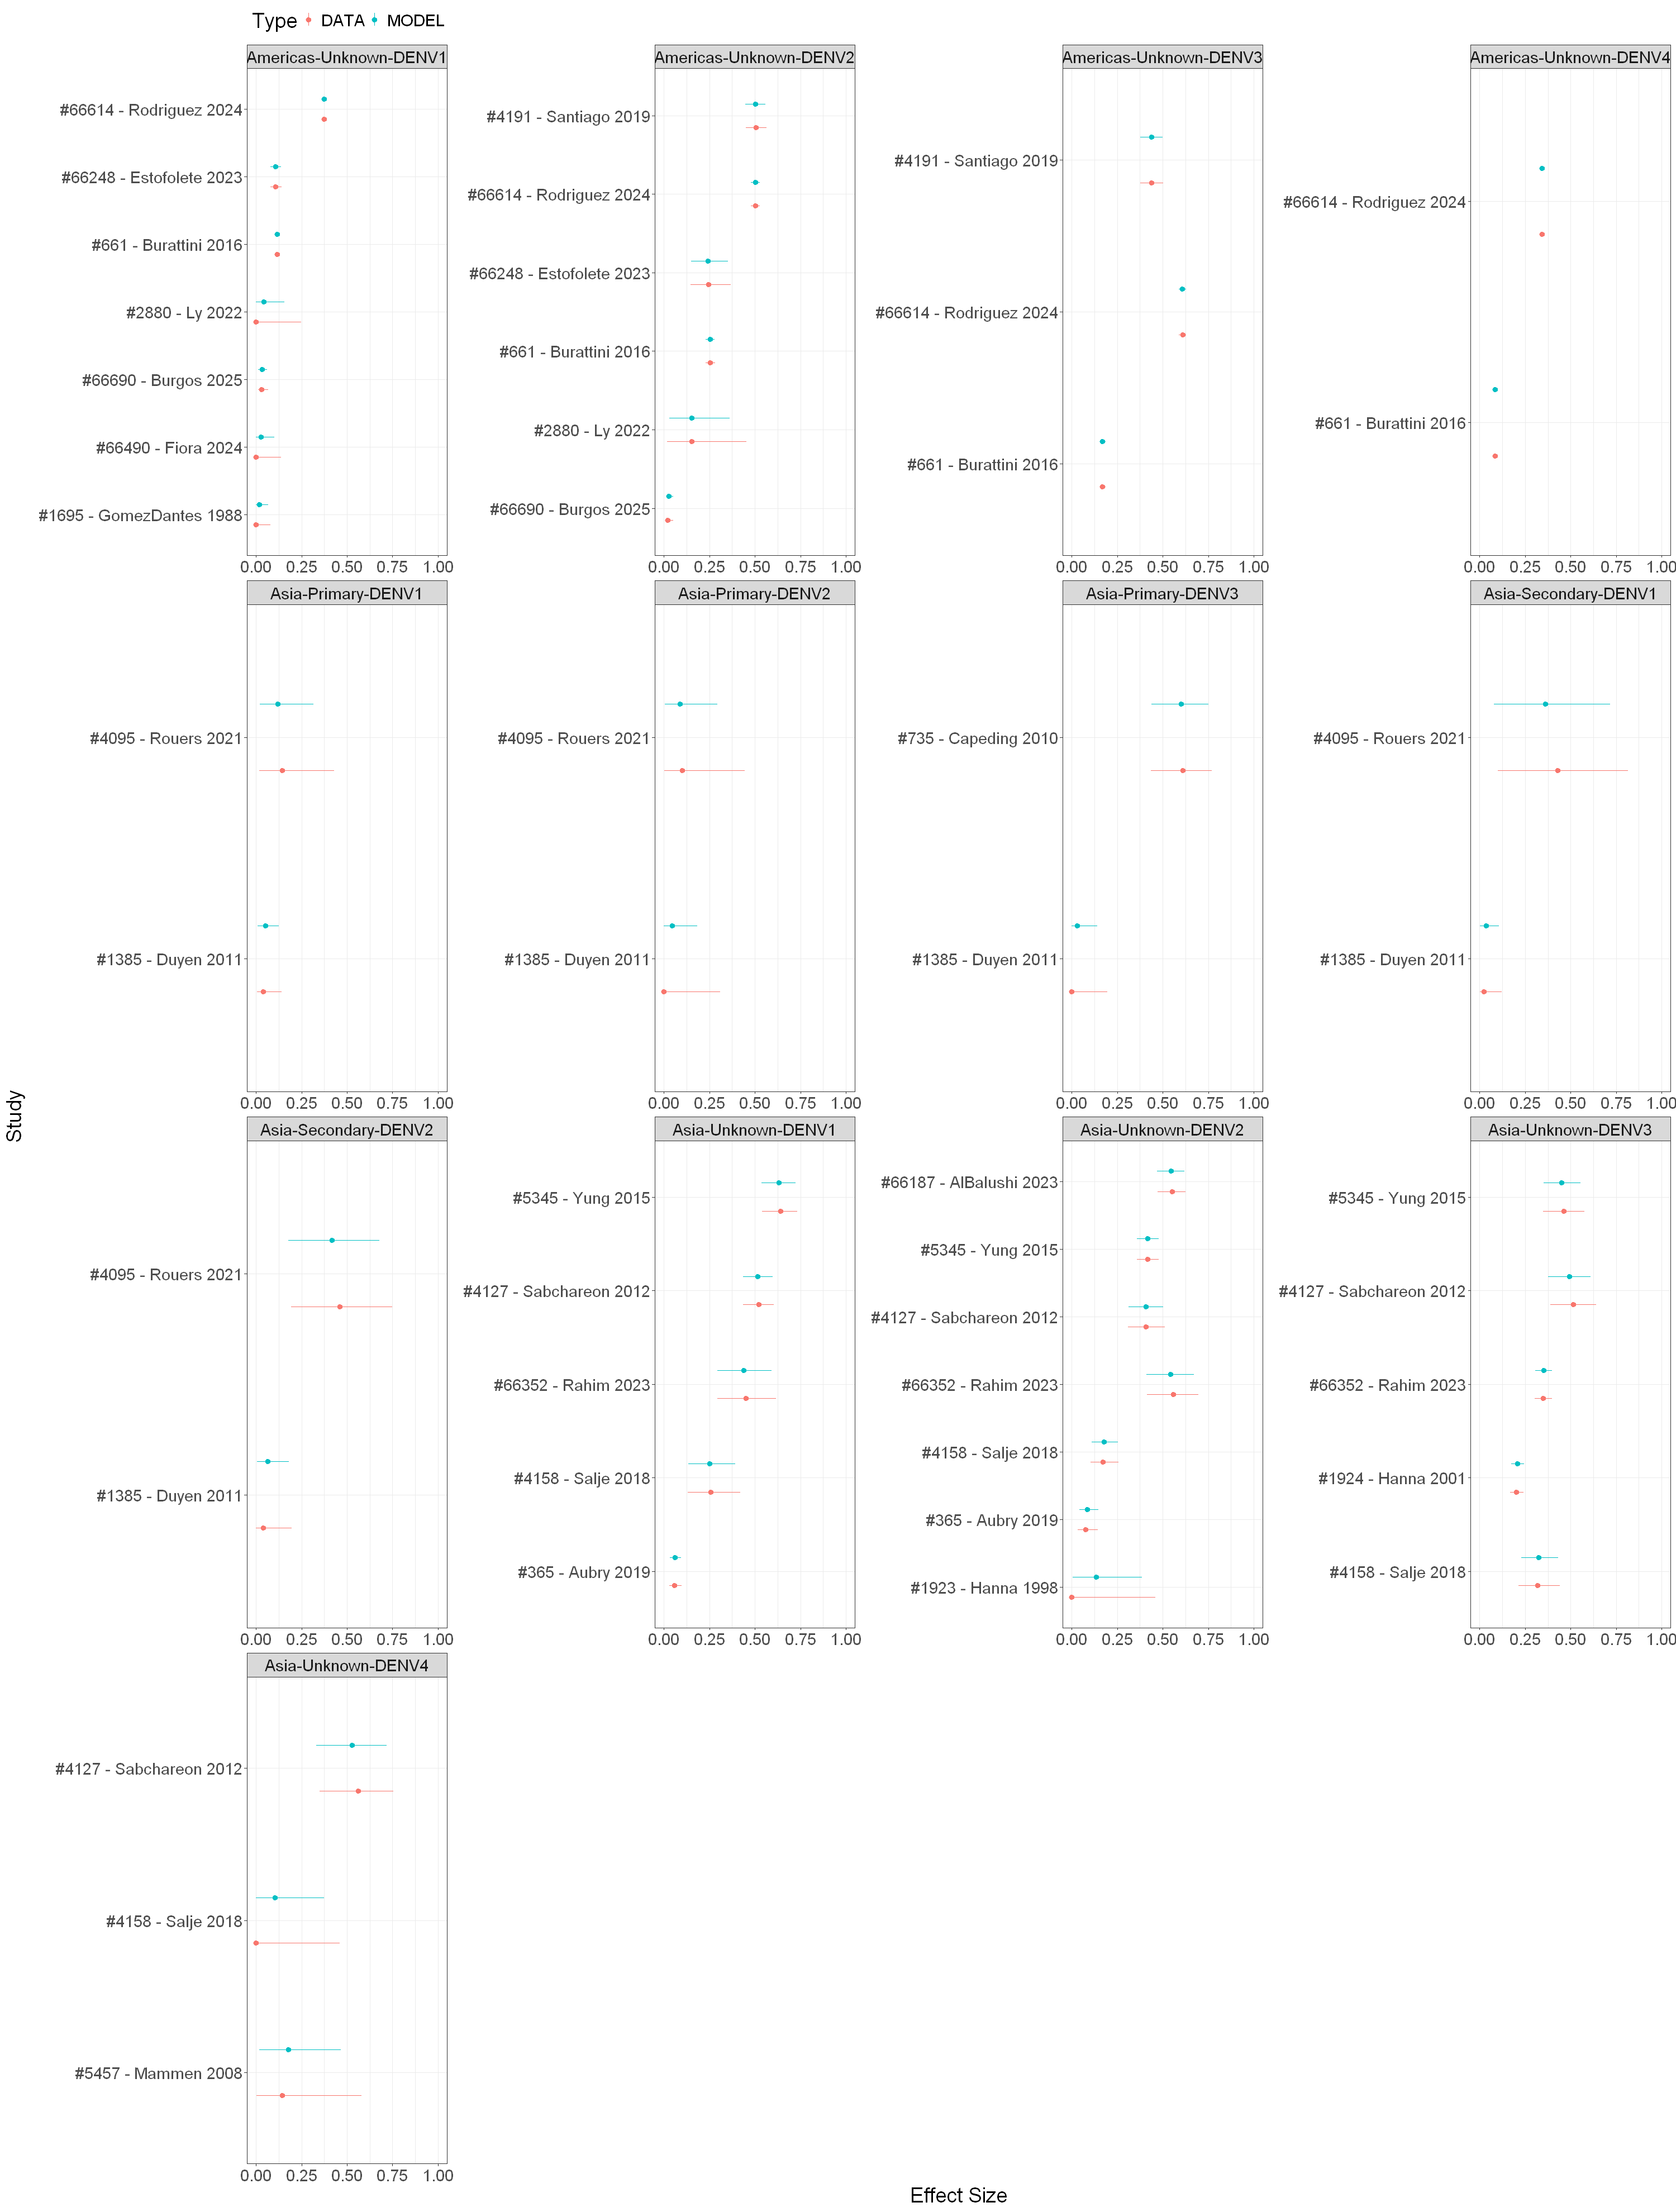

In [7]:
options(repr.plot.width = 25, repr.plot.height = 33)
fit_vis_df %>% 
    ggplot(aes(x = reorder(CovidenceID, PointEst), y = PointEst, ymin = Lower, ymax = Upper, colour = Type)) +
        geom_pointrange(position = position_dodge(width = 0.6)) + 
        coord_flip() + 
        theme(text = element_text(size = 22), legend.position = "top", legend.justification = "left") +
        xlab("Study") + ylab("Effect Size") + ylim(0,1) + 
        facet_wrap(vars(Scenario), scales = "free", ncol = 4)

if(save_output){
    ggsave(file.path(visuals_output_dir, "png", paste0("ModelFitPerStudy", ".png")), width = 25, height = 33, unit = "in", dpi = 800, limitsize = FALSE)
    ggsave(file.path(visuals_output_dir, "eps", paste0("ModelFitPerStudy", ".eps")), width = 25, height = 33, unit = "in", dpi = 800, limitsize = FALSE)
    ggsave(file.path(visuals_output_dir, "pdf", paste0("ModelFitPerStudy", ".pdf")), width = 25, height = 33, unit = "in", dpi = 800, limitsize = FALSE)
}

# Scenario Summary
Here we generate a visual showing the pooled estimate for each scenario.

In [8]:
input_data %>% names
ref_region = input_data$ref_region
non_ref_region = ifelse(ref_region == "Asia", "Americas", "Asia")
ref_serotype_exposure = input_data$ref_serotype_exposure
ref_scenario = input_data$ref_scenario


#Name of what cases are considered severe
severe_name = "Severe"
if(sev_class_type == "1997type"){
    severe_name = "DHF/DSS"
}else if(sev_class_type == "2009type"){
    severe_name = "SD"
}else{
    severe_name = "Hospitalised"
}


[1] "data_list"             "outcome_df"            "study_df"             
[4] "scenario_df"           "char_mat_guide"        "ref_region"           
[7] "ref_serotype_exposure" "ref_scenario"

In [9]:
non_ref_seroprior = input_data$char_mat_guide %>% filter(CharMatIndex >0) %>% pull(SeroPriorExp) %>% as.character
scenario_labels = c(ref_scenario, 
                    paste0(ref_region, "-", non_ref_seroprior),
                    paste0(non_ref_region, "-", c(ref_serotype_exposure, non_ref_seroprior))
                   )

In [10]:
#Get the scenario estimates, which are given as p from the model
p_estimates = summary(model_results, pars = "p")$summary %>% data.frame
p_estimates = p_estimates %>% select(mean, X2.5., X97.5.) %>% 
    rename(PointEst = mean, Lower = X2.5., Upper = X97.5.) %>% mutate(Scenario = scenario_labels)

scenario_df = input_data$scenario_df %>% left_join(het_results %>% select(Scenario, I2_est), by = "Scenario")
scenario_vis_df = scenario_df %>% left_join(p_estimates, by = "Scenario") %>% 
                    filter(!is.na(CharMatIndex)) %>% 
                    mutate(DispVal = sprintf("%.2f%% [%.2f to %.2f%%]", 100*PointEst, 100*Lower, 100*Upper)) %>%
                    mutate(DispHet = ifelse(is.na(I2_est), "-", sprintf("%.2f%%", I2_est * 100))) %>% 
                    mutate(Pooled = ifelse(Inclusion == "Included", "Pooled", "Not Pooled"))
                    
scenario_vis_df  

SeroPriorExp,Region,Scenario,NumStudies,Severe,NonSevere,N,Inclusion,ScenIndex,CharMatIndex,I2_est,PointEst,Lower,Upper,DispVal,DispHet,Pooled
<fct>,<fct>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
Unknown-DENV1,Americas,Americas-Unknown-DENV1,7,7496,17413,24909,Included,1,1,0.9134498,0.12700327,0.033684200,0.3368358,12.70% [3.37 to 33.68%],91.34%,Pooled
Unknown-DENV2,Americas,Americas-Unknown-DENV2,6,1326,2165,3491,Included,2,2,0.9609659,0.19570230,0.065445199,0.3832812,19.57% [6.54 to 38.33%],96.10%,Pooled
Unknown-DENV3,Americas,Americas-Unknown-DENV3,3,1770,2555,4325,Included,3,3,0.9965774,0.25051171,0.075754151,0.4875047,25.05% [7.58 to 48.75%],99.66%,Pooled
Unknown-DENV4,Americas,Americas-Unknown-DENV4,2,2011,6218,8229,Included,4,4,0.9993254,0.15210745,0.022976660,0.3991791,15.21% [2.30 to 39.92%],99.93%,Pooled
Primary-DENV1,Americas,Americas-Primary-DENV1,0,0,0,0,Excluded,-1,5,NA,0.08007242,0.005711458,0.3829137,8.01% [0.57 to 38.29%],-,Not Pooled
Primary-DENV2,Americas,Americas-Primary-DENV2,0,0,0,0,Excluded,-1,6,NA,0.06677528,0.002096509,0.3643483,6.68% [0.21 to 36.43%],-,Not Pooled
Primary-DENV3,Americas,Americas-Primary-DENV3,0,0,0,0,Excluded,-1,7,NA,0.15761726,0.003670771,0.6788601,15.76% [0.37 to 67.89%],-,Not Pooled
Secondary-DENV1,Americas,Americas-Secondary-DENV1,0,0,0,0,Excluded,-1,8,NA,0.13423162,0.005687083,0.5896893,13.42% [0.57 to 58.97%],-,Not Pooled
Secondary-DENV2,Americas,Americas-Secondary-DENV2,0,0,0,0,Excluded,-1,-1,NA,0.13609469,0.023347442,0.3828973,13.61% [2.33 to 38.29%],-,Not Pooled


pdf 
  2

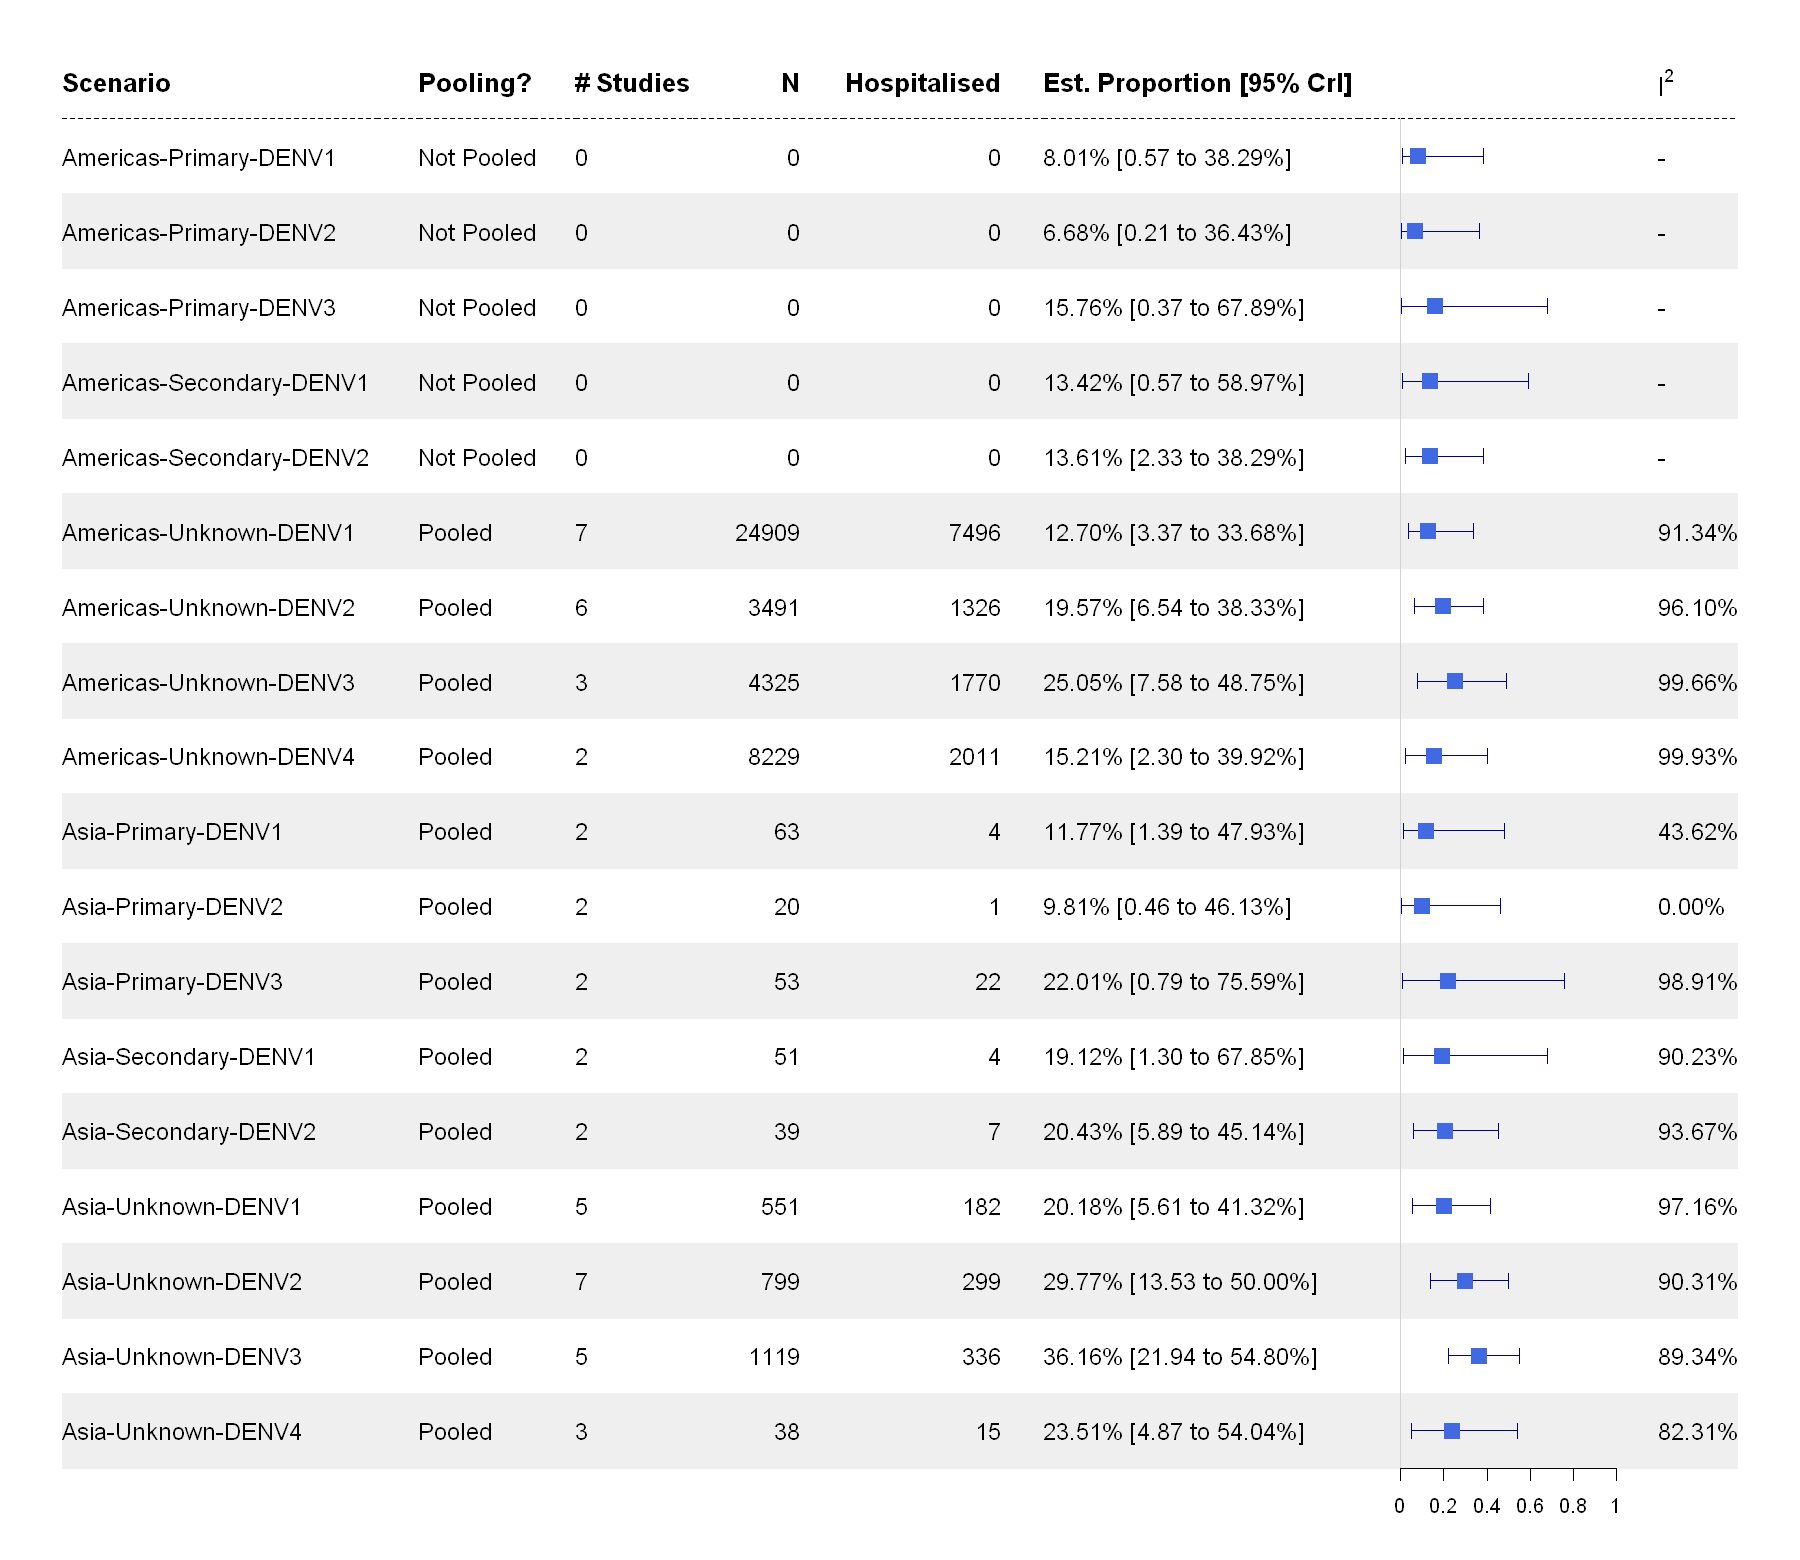

In [11]:
#Generate a forest plot specifically for this severity class
options(repr.plot.width = 15, repr.plot.height = 13)
scenario_plot = scenario_vis_df %>% arrange(Scenario) %>%
    forestplot(labeltext = c(Scenario, Pooled, NumStudies, N, Severe, DispVal, DispHet),
                mean = PointEst, lower = Lower, upper = Upper,
                xticks = seq(0, 1, by = 0.2), ci.vertices = TRUE, boxsize = 0.2,
                align = c("l", "l", "l", "r", "r"), graphwidth = unit(1.8, "in")
              ) |>
    fp_add_lines(h_2 = gpar(lty = 2)) |>
    fp_set_style(box = "royalblue", line = gpar(col = "darkblue"), summary = "royalblue",
                txt_gp = fpTxtGp(cex =1.2, ticks = gpar(cex = 1))) |>
    fp_add_header(
                    Scenario = "Scenario", 
                    Pooled = "Pooling?",
                    NumStudies = "# Studies",
                    N = "N", 
                    Severe = severe_name, 
                    DispVal = "Est. Proportion [95% CrI]",
                    DispHet = expression(I^{2})
    ) |> fp_decorate_graph(graph.pos = 7) |> fp_set_zebra_style("#EFEFEF")

if(save_output){
    #save_plot(scenario_plot, file.path(visuals_output_dir, paste0("SubgroupForest_",  sev_class_type, ".png")), 15, 13, "in", 600)
    save_plot_all_formats(scenario_plot, visuals_output_dir, paste0("SubgroupForest_",  sev_class_type), 15, 13, "in", 600)
}
scenario_plot

# Odds Ratios versus Reference
Here we generate a visual of the odds ratios for each effect versus the reference class.

In [12]:
or_labels = c("Intercept", non_ref_seroprior, non_ref_region)
or_labels

[1] "Intercept"       "Unknown-DENV1"   "Unknown-DENV2"   "Unknown-DENV3"  
 [5] "Unknown-DENV4"   "Primary-DENV1"   "Primary-DENV2"   "Primary-DENV3"  
 [9] "Secondary-DENV1" "Americas"

In [13]:
process_or_beta = function(par_name){
    beta_or_est  = summary(model_results, pars = c(par_name))$summary %>% data.frame %>%
                mutate(Label = or_labels) %>% select(Label, mean, X2.5., X97.5.) %>% 
                rename(PointEst = mean, Lower = X2.5., Upper = X97.5.)
    return(beta_or_est)
}
log_beta_or_est = process_or_beta("log_or_beta") %>% select(-Label) %>% rename(LogPointEst = PointEst, LogLower = Lower, LogUpper = Upper)
beta_or_est = process_or_beta("or_beta")

beta_or_est = cbind(beta_or_est, log_beta_or_est)

In [14]:
#We don't need the intercept
ref_seroexp_label = data.frame(Label = paste0("Versus ", ref_serotype_exposure), PointEst = NA, Lower = NA, Upper  = NA, LogPointEst = NA, LogLower = NA, LogUpper = NA, DispVal = NA, LogDispVal = NA)
ref_region_label = data.frame(Label = paste0("Versus ", ref_region), PointEst = NA, Lower = NA, Upper  = NA, LogPointEst = NA, LogLower = NA, LogUpper = NA, DispVal = NA, LogDispVal = NA)
beta_or_vis_df = beta_or_est %>% filter(Label != "Intercept") %>% 
                    mutate(DispVal = sprintf("%.2f [%.2f to %.2f]", PointEst, Lower, Upper)) %>% 
                    mutate(LogDispVal = sprintf("%.2f [%.2f to %.2f]", LogPointEst, LogLower, LogUpper))

or_seroexp_part = beta_or_vis_df %>% filter(Label != non_ref_region) %>% mutate(Label = paste0("     ", Label))
or_region_part = beta_or_vis_df %>% filter(Label == non_ref_region)%>% mutate(Label = paste0("     ", Label))

beta_or_vis_df = rbind(ref_seroexp_label, or_seroexp_part, ref_region_label, or_region_part)

#Add significance labels
beta_or_vis_df = beta_or_vis_df %>% mutate(DispVal = ifelse(((Lower > 1) | (Upper < 1)), paste0(DispVal, "*"), DispVal),
                                          LogDispVal = ifelse(((LogLower > 0) | (LogUpper < 0)), paste0(LogDispVal, "*"), LogDispVal))

In [15]:
beta_or_vis_df

,Label,PointEst,Lower,Upper,LogPointEst,LogLower,LogUpper,DispVal,LogDispVal
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
1,Versus Secondary-DENV2,NA,NA,NA,NA,NA,NA,NA,NA
or_beta[2],Unknown-DENV1,1.4022698,0.18856879,5.040312,-0.007758869,-1.6682924,1.6174680,1.40 [0.19 to 5.04],-0.01 [-1.67 to 1.62]
or_beta[3],Unknown-DENV2,2.3604776,0.39912470,7.684434,0.578324979,-0.9184814,2.0391968,2.36 [0.40 to 7.68],0.58 [-0.92 to 2.04]
or_beta[4],Unknown-DENV3,3.1565351,0.60095655,10.055665,0.893543145,-0.5092327,2.3081361,3.16 [0.60 to 10.06],0.89 [-0.51 to 2.31]
or_beta[5],Unknown-DENV4,1.7995792,0.17554301,7.044168,0.149866200,-1.7398712,1.9522001,1.80 [0.18 to 7.04],0.15 [-1.74 to 1.95]
or_beta[6],Primary-DENV1,0.8313010,0.05002790,4.117996,-0.894829533,-2.9951744,1.4153664,0.83 [0.05 to 4.12],-0.89 [-3.00 to 1.42]
or_beta[7],Primary-DENV2,0.7020119,0.01922041,3.882411,-1.317105513,-3.9517824,1.3564563,0.70 [0.02 to 3.88],-1.32 [-3.95 to 1.36]
or_beta[8],Primary-DENV3,2.2564934,0.03738109,13.463056,-0.266452834,-3.2865904,2.5999493,2.26 [0.04 to 13.46],-0.27 [-3.29 to 2.60]
or_beta[9],Secondary-DENV1,1.6697004,0.05328647,9.217242,-0.360660427,-2.9320729,2.2210759,1.67 [0.05 to 9.22],-0.36 [-2.93 to 2.22]


pdf 
  2

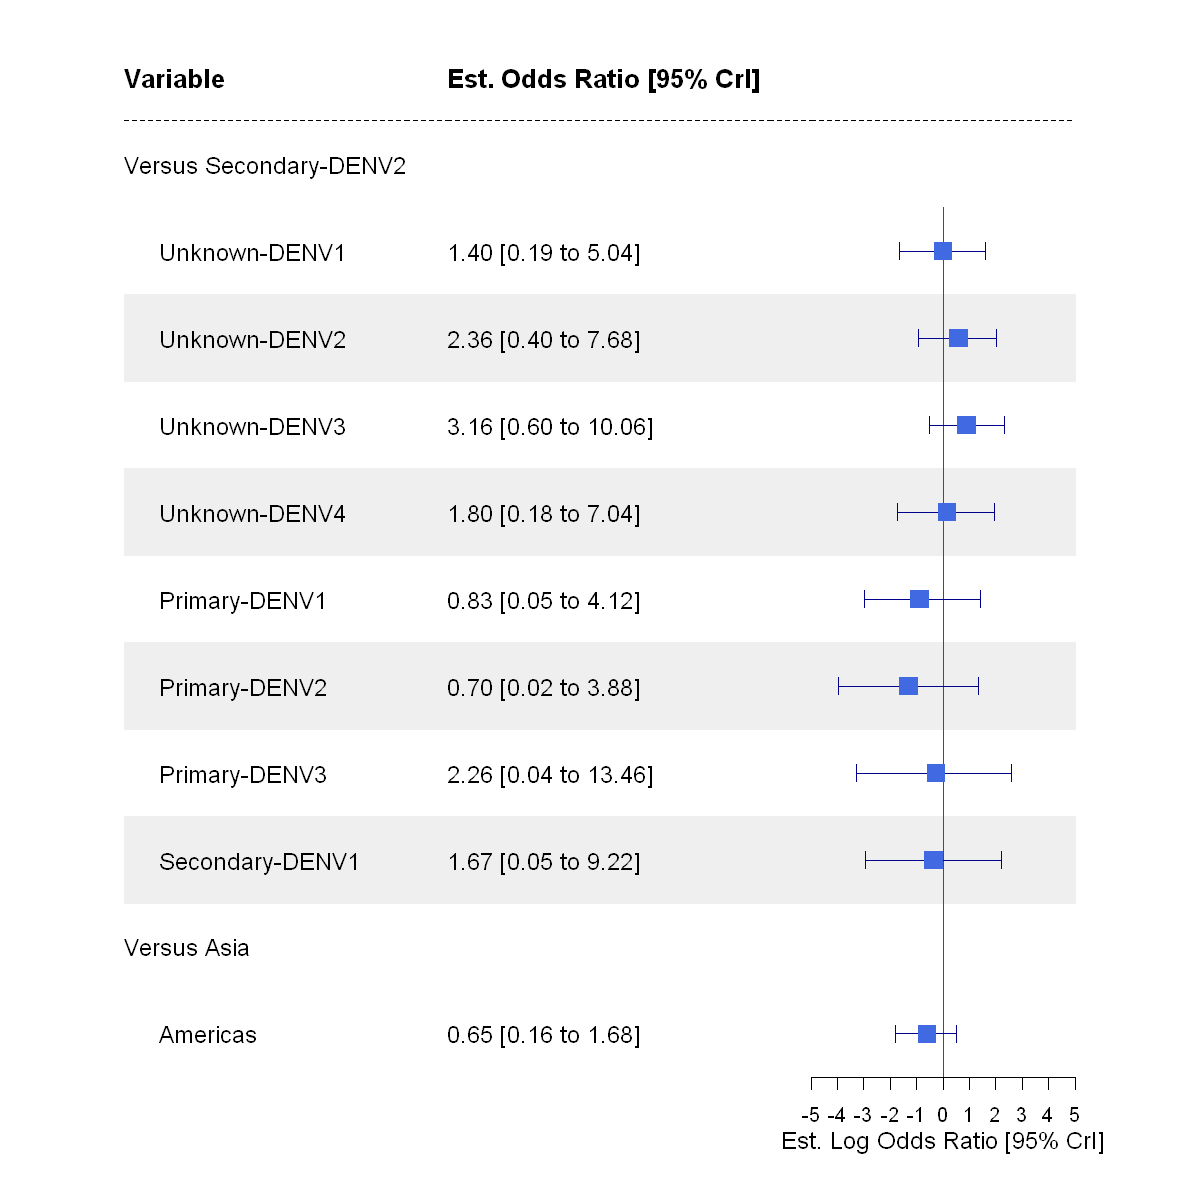

In [16]:
options(repr.plot.width = 10, repr.plot.height = 10)
or_versus_ref_plot = beta_or_vis_df %>%forestplot(labeltext = c(Label, DispVal), zero = 0,
                mean = LogPointEst, lower = LogLower, upper = LogUpper,
                xticks = seq(-5, 5, by = 1), ci.vertices = TRUE, boxsize = 0.2,
                align = c("l", "l"), graphwidth = unit(2.2, "in"), xlab = "Est. Log Odds Ratio [95% CrI]"
              ) |>
    fp_add_lines(h_2 = gpar(lty = 2)) |>
    fp_set_style(box = "royalblue", line = gpar(col = "darkblue"), summary = "royalblue", zero = "red",
                txt_gp = fpTxtGp(cex =1.2, ticks = gpar(cex = 1), xlab = gpar(cex = 1.2))) |>
    fp_add_header(
                    Label = "Variable", 
                    DispVal = "Est. Odds Ratio [95% CrI]"
                    #LogDispVal = "Est. Log Odds Ratio [95% CrI]"
    ) |> fp_set_zebra_style("#EFEFEF")

if(save_output){
    #save_plot(or_versus_ref_plot, file.path(visuals_output_dir, paste0("ORvsRef_",  sev_class_type, ".png")), 10, 10, "in", 600)
    save_plot_all_formats(or_versus_ref_plot, visuals_output_dir, paste0("ORvsRef_",  sev_class_type), 10, 10, "in", 600)
}
or_versus_ref_plot

# Odds Ratio Pairwise Comparison (Serotype - Prior Exposure)
Here, we generate a visual showing pairs of serotype-prior exposure effects and the odds ratio for severity between them (including the reference class and whether the difference was significant or not).

In [17]:
char_mat_guide = input_data$char_mat_guide
char_mat_guide

SeroPriorExp,CharMatIndex
<fct>,<dbl>
Unknown-DENV1,1
Unknown-DENV2,2
Unknown-DENV3,3
Unknown-DENV4,4
Primary-DENV1,5
Primary-DENV2,6
Primary-DENV3,7
Secondary-DENV1,8
Secondary-DENV2,-1


In [18]:
#We create a visual to show pairwise odds ratios (these would be in the sero_prior_or_ratios matrix)
sero_prior_mat = summary(model_results, pars = "sero_prior_or_ratios")$summary %>% data.frame %>%
                select(mean, X2.5., X97.5.) %>%
                rename(PointEst = mean, Lower = X2.5., Upper = X97.5.) %>%
                mutate(Name = rownames(.)) %>%
                separate(Name, sep = "\\[|,|\\]", into = c(NA, "ROW", "COL", NA)) %>% 
                mutate(ROW = as.numeric(ROW), COL = as.numeric(COL)) %>%
                filter(COL > ROW) %>% 
                left_join(char_mat_guide, by = c("ROW" = "CharMatIndex")) %>% #Join the indices based on the input char_mat_guide
                rename(RowScenario = SeroPriorExp) %>% 
                left_join(char_mat_guide, by = c("COL" = "CharMatIndex")) %>%
                rename(ColScenario = SeroPriorExp) %>% 
                select(-c(ROW, COL))

log_sero_prior_mat  = summary(model_results, pars = "log_sero_prior_or_ratios")$summary %>% data.frame %>%
                select(mean, X2.5., X97.5.) %>%
                rename(LogPointEst = mean, LogLower = X2.5., LogUpper = X97.5.) %>% mutate(Name = rownames(.)) %>%
                separate(Name, sep = "\\[|,|\\]", into = c(NA, "ROW", "COL", NA)) %>% 
                mutate(ROW = as.numeric(ROW), COL = as.numeric(COL)) %>%
                filter(COL > ROW) %>%
                select(-c(ROW, COL))
sero_prior_mat = cbind(sero_prior_mat, log_sero_prior_mat)

In [19]:
versus_ref_portion = beta_or_est %>% filter(!Label %in% c("Intercept", non_ref_region)) %>%
                        mutate(ColScenario = ref_serotype_exposure) %>% rename(RowScenario = Label)
#We add in the part of the matrix versus the reference class (the reference is the denominator of the OR)

sero_prior_mat_vis = sero_prior_mat %>% rbind(versus_ref_portion) %>% 
                    mutate(Significance = ifelse(((Lower > 1) | (Upper < 1)),"Significant", "Not Significant")) %>% #Check for significant OR   
                    arrange(desc(Significance), desc(PointEst)) %>% 
                    mutate(DispVal = sprintf("%.2f [%.2f to %.2f]", PointEst, Lower, Upper),
                          LogDispVal = sprintf("%.2f [%.2f to %.2f]", LogPointEst, LogLower, LogUpper))
sero_prior_mat_vis

,PointEst,Lower,Upper,RowScenario,ColScenario,LogPointEst,LogLower,LogUpper,Significance,DispVal,LogDispVal
,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
"log_sero_prior_or_ratios[3,6]",23.6824346,0.605663351,129.910210,Unknown-DENV3,Primary-DENV2,2.210648658,-0.5014310,4.8668435,Not Significant,23.68 [0.61 to 129.91],2.21 [-0.50 to 4.87]
"log_sero_prior_or_ratios[2,6]",17.2936243,0.421689820,96.959328,Unknown-DENV2,Primary-DENV2,1.895430493,-0.8634853,4.5742916,Not Significant,17.29 [0.42 to 96.96],1.90 [-0.86 to 4.57]
"log_sero_prior_or_ratios[4,6]",13.6337289,0.217358424,79.550703,Unknown-DENV4,Primary-DENV2,1.466971713,-1.5262084,4.3763944,Not Significant,13.63 [0.22 to 79.55],1.47 [-1.53 to 4.38]
"log_sero_prior_or_ratios[3,7]",11.6560017,0.167988659,75.871854,Unknown-DENV3,Primary-DENV3,1.159995979,-1.7838588,4.3290458,Not Significant,11.66 [0.17 to 75.87],1.16 [-1.78 to 4.33]
"log_sero_prior_or_ratios[3,5]",10.3997535,0.575992701,44.732498,Unknown-DENV3,Primary-DENV1,1.788372677,-0.5516604,3.8007001,Not Significant,10.40 [0.58 to 44.73],1.79 [-0.55 to 3.80]
"log_sero_prior_or_ratios[1,6]",10.3922989,0.201436762,58.192287,Unknown-DENV1,Primary-DENV2,1.309346644,-1.6022799,4.0637526,Not Significant,10.39 [0.20 to 58.19],1.31 [-1.60 to 4.06]
"log_sero_prior_or_ratios[2,7]",8.5808353,0.118190161,55.665155,Unknown-DENV2,Primary-DENV3,0.844777813,-2.1354604,4.0193543,Not Significant,8.58 [0.12 to 55.67],0.84 [-2.14 to 4.02]
"log_sero_prior_or_ratios[3,8]",8.5361294,0.241082370,46.468289,Unknown-DENV3,Secondary-DENV1,1.254203572,-1.4226166,3.8387701,Not Significant,8.54 [0.24 to 46.47],1.25 [-1.42 to 3.84]
"log_sero_prior_or_ratios[2,5]",7.8144048,0.395238578,33.458276,Unknown-DENV2,Primary-DENV1,1.473154512,-0.9282657,3.5102991,Not Significant,7.81 [0.40 to 33.46],1.47 [-0.93 to 3.51]


pdf 
  2

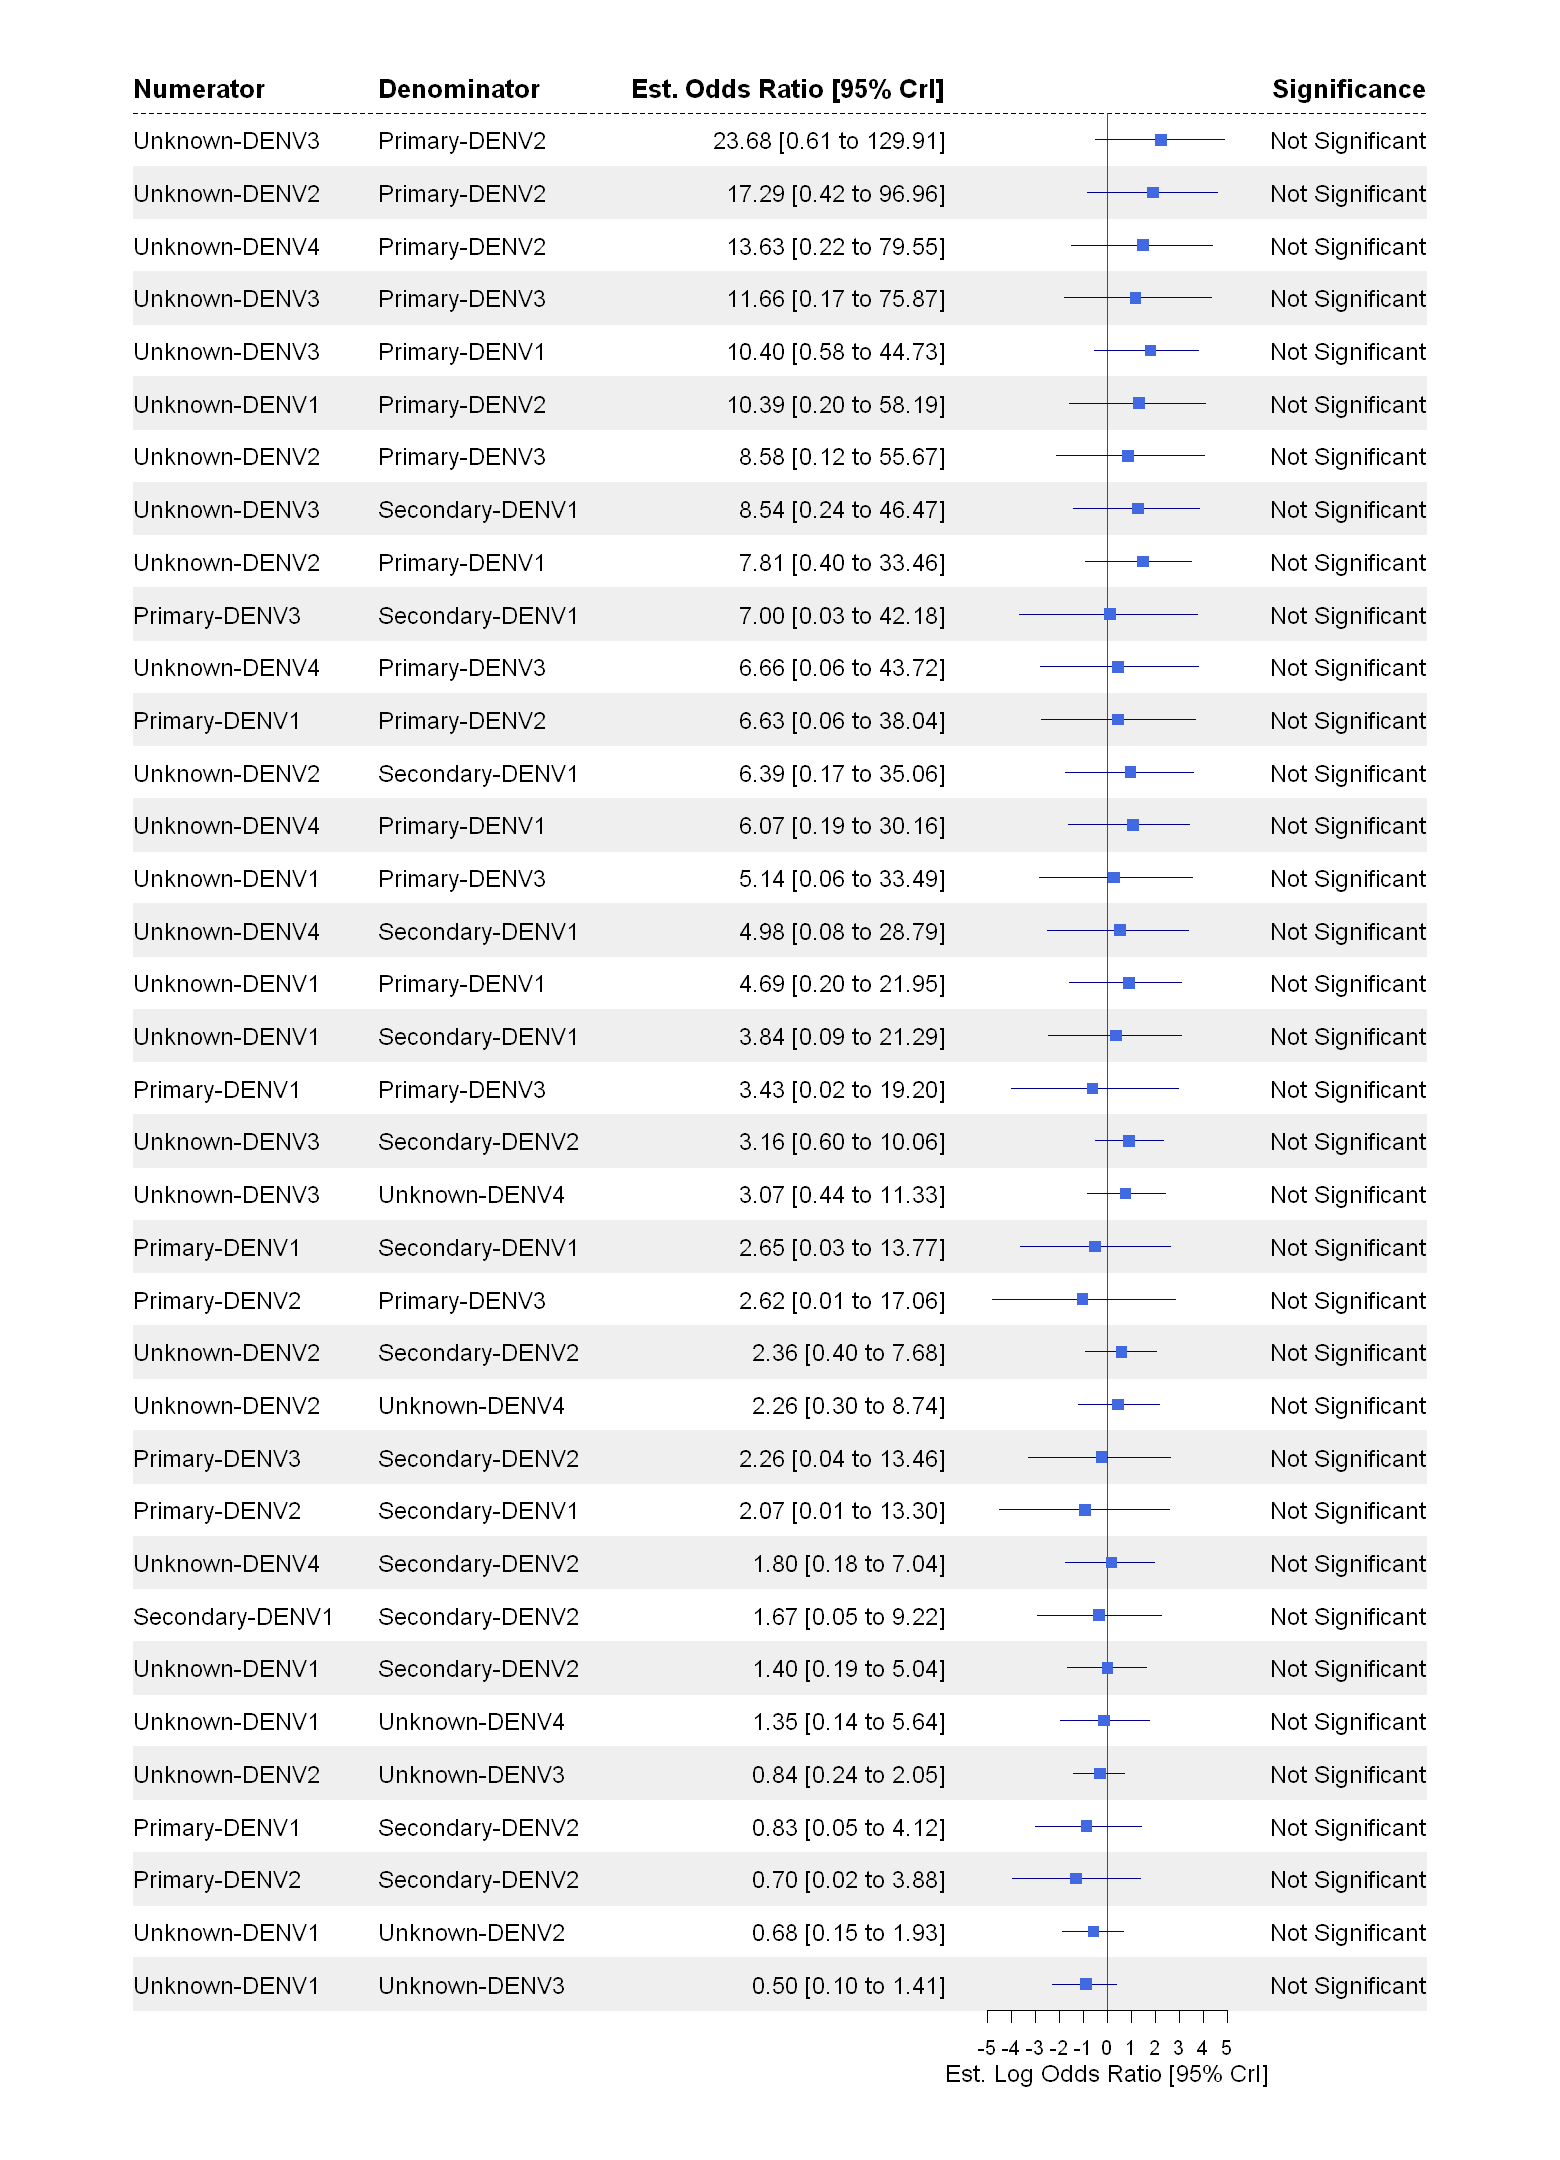

In [20]:
options(repr.plot.width = 13, repr.plot.height = 18)

axis_lim = 5
sero_prior_comp_plot = sero_prior_mat_vis %>%
                forestplot(labeltext = c(RowScenario, ColScenario, DispVal, Significance), zero = 0,
                mean = LogPointEst, lower = LogLower, upper = LogUpper, clip = c(-axis_lim, axis_lim),
                xticks = seq(-axis_lim, axis_lim, by = as.integer(axis_lim/5)), boxsize = 0.2,
                align = c("l", "l", "r", "r"), graphwidth = unit(2, "in"), ci.vertices.height = 0.2, xlab = "Est. Log Odds Ratio [95% CrI]"
              ) |>
    fp_add_lines(h_2 = gpar(lty = 2)) |>
    fp_set_style(box = "royalblue", line = gpar(col = "darkblue"), zero = "red", summary = "royalblue",
                txt_gp = fpTxtGp(cex =1.2, ticks = gpar(cex = 1), xlab = gpar(cex = 1.2))) |>
    fp_add_header(
                    RowScenario = "Numerator", 
                    ColScenario = "Denominator", 
                    DispVal = "Est. Odds Ratio [95% CrI]",
                    #LogDispVal = "Est. Log Odds Ratio [95% CrI]",
                    Significance = "Significance"
    ) |> fp_set_zebra_style("#EFEFEF") |> fp_decorate_graph(graph.pos = 4)
if(save_output){
    #save_plot(sero_prior_comp_plot, file.path(visuals_output_dir, paste0("SeroPriorComp_",  sev_class_type, ".png")), 15, 18, "in", 600)
    save_plot_all_formats(sero_prior_comp_plot, visuals_output_dir, paste0("SeroPriorComp_",  sev_class_type), 15, 18, "in", 600)
}
sero_prior_comp_plot

pdf 
  2

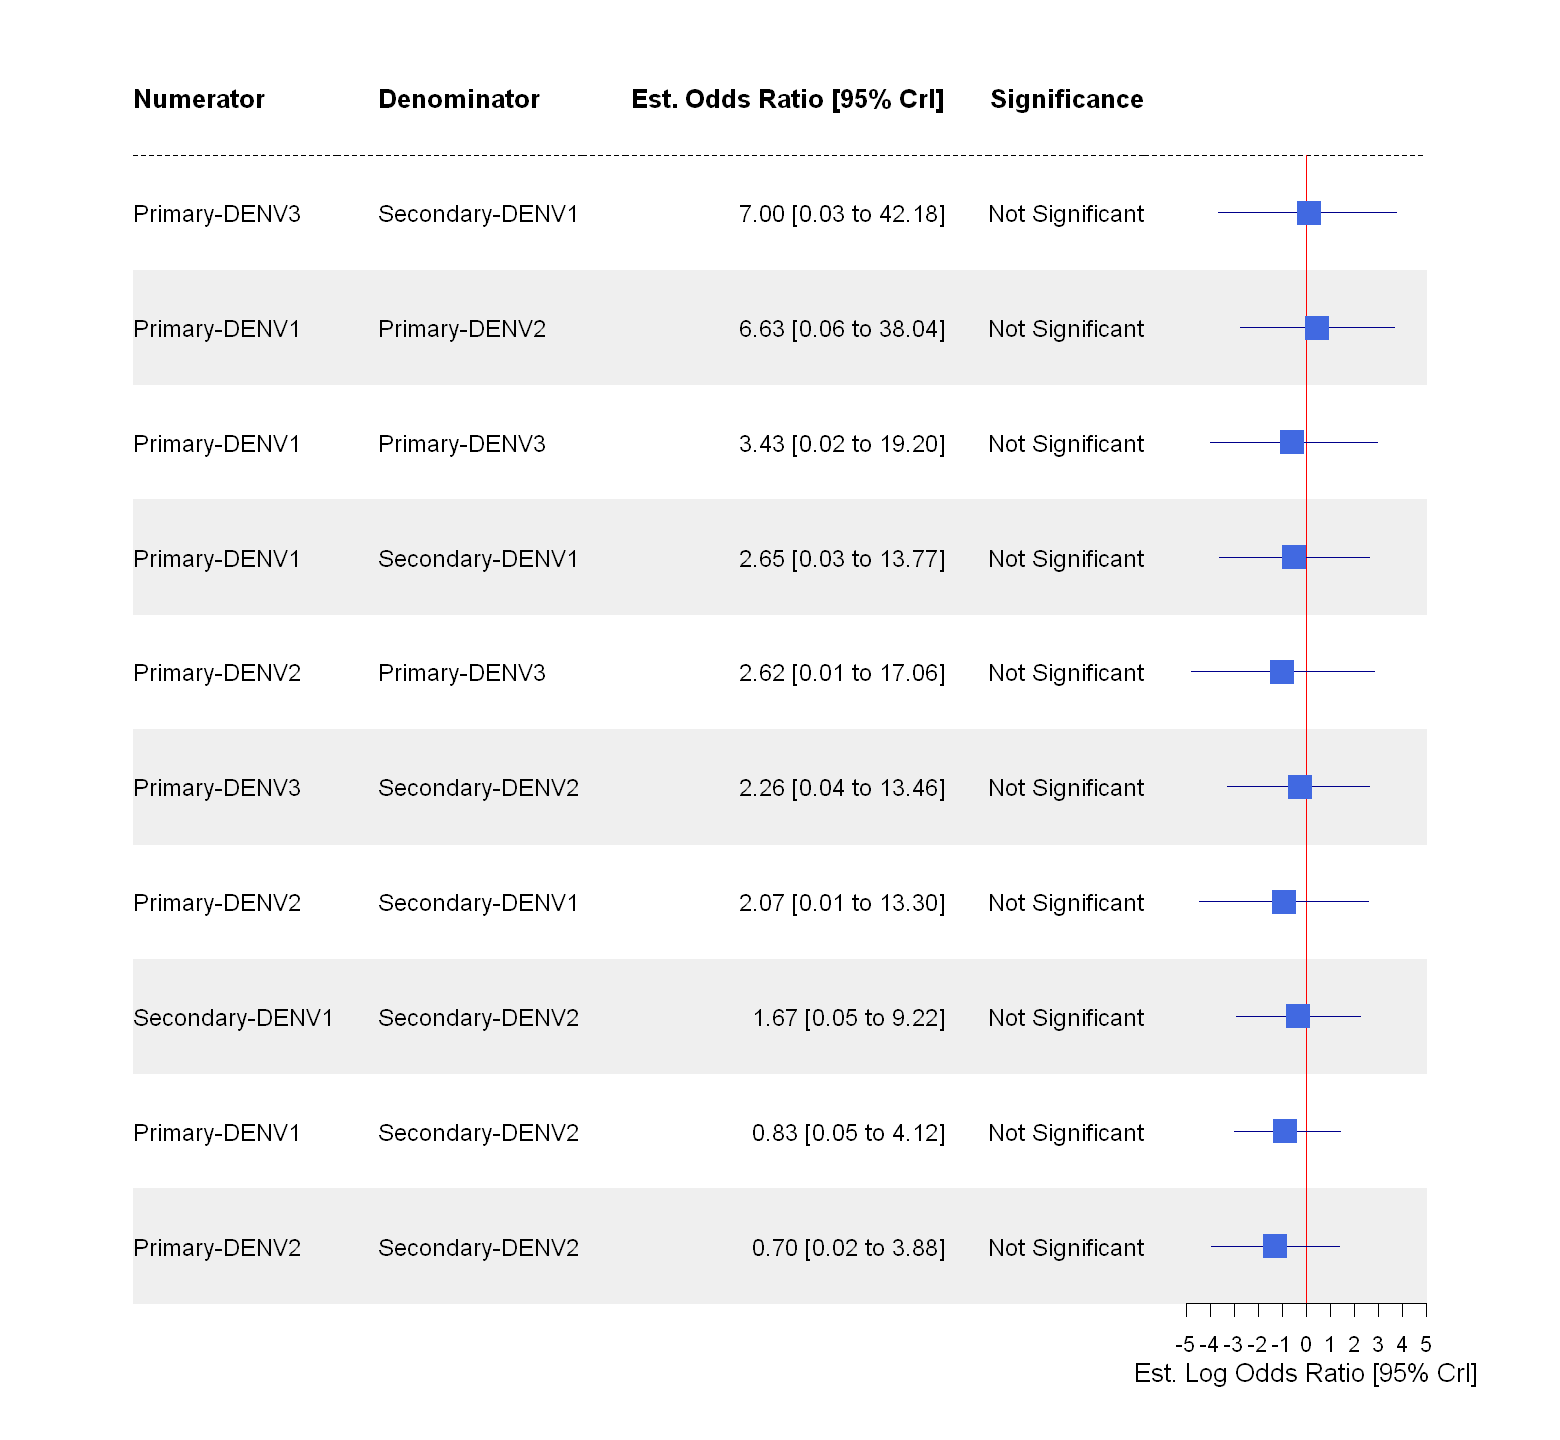

In [21]:
#Same plot as abive but without the unknowns
options(repr.plot.width = 13, repr.plot.height = 12)
axis_lim = 5
sero_prior_comp_plot_known = sero_prior_mat_vis %>% filter(!(str_detect(RowScenario, "Unknown") | str_detect(ColScenario, "Unknown"))) %>%
                forestplot(labeltext = c(RowScenario, ColScenario, DispVal, Significance), zero = 0, 
                clip = c(-axis_lim, axis_lim), 
                mean = LogPointEst, lower = LogLower, upper = LogUpper,
                xticks = seq(-axis_lim, axis_lim, by = as.integer(axis_lim/5)), 
                ci.vertices = FALSE, boxsize = 0.2, ci.vertices.height = 0.2, 
                align = c("l", "l", "r", "r"), graphwidth = unit(2, "in"), xlab = "Est. Log Odds Ratio [95% CrI]"
              ) |>
    fp_add_lines(h_2 = gpar(lty = 2)) |>
    fp_set_style(box = "royalblue", line = gpar(col = "darkblue"), zero = "red", summary = "royalblue",
                txt_gp = fpTxtGp(cex =1.2, ticks = gpar(cex = 1.1), xlab = gpar(cex = 1.3))) |>
    fp_add_header(
                    RowScenario = "Numerator", 
                    ColScenario = "Denominator", 
                    DispVal = "Est. Odds Ratio [95% CrI]",
                    #LogDispVal = "Est. Log Odds Ratio [95% CrI]",
                    Significance = "Significance"
    ) |> fp_set_zebra_style("#EFEFEF") |> fp_decorate_graph(graph.pos = 5)
if(save_output){
    #save_plot(sero_prior_comp_plot_known, file.path(visuals_output_dir, paste0("SeroPriorComp_Known_",  sev_class_type, ".png")), 13, 12, "in", 600)
    save_plot_all_formats(sero_prior_comp_plot_known, visuals_output_dir, paste0("SeroPriorComp_Known_",  sev_class_type), 13, 12, "in", 600)
}
sero_prior_comp_plot_known

# Scenario Forests
In this section, we make individual forest plots for each of the scenarios where we pool data.

In [22]:
theta_df = summary(model_results, pars = "theta")$summary %>% data.frame %>% 
                select(mean, X2.5., X97.5.) %>% rename(PointEst = mean, Lower = X2.5., Upper = X97.5.)

outcome_ests = outcome_df %>% cbind(theta_df) %>% 
                mutate(DispVal = sprintf("%.2f%% [%.2f to %.2f%%]", 100*PointEst, 100*Lower, 100*Upper))

outcome_ests

,ID,CovidenceID,Region,Serotype,PriorExp,NonSevere,Severe,N,SeroPriorExp,Scenario,RowIndex,ColIndex,RegIndex,PointEst,Lower,Upper,DispVal
,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
theta[1],0315,#66490 - Fiora 2024,Americas,DENV1,Unknown,25,0,25,Unknown-DENV1,Americas-Unknown-DENV1,1,1,1,0.02612863,2.823631e-04,0.10028781,2.61% [0.03 to 10.03%]
theta[2],0297,#1923 - Hanna 1998,Asia,DENV2,Unknown,6,0,6,Unknown-DENV2,Asia-Unknown-DENV2,2,2,2,0.13317348,6.255593e-03,0.38743048,13.32% [0.63 to 38.74%]
theta[3],0024,#1924 - Hanna 2001,Asia,DENV3,Unknown,397,101,498,Unknown-DENV3,Asia-Unknown-DENV3,3,3,2,0.20710489,1.726360e-01,0.24369261,20.71% [17.26 to 24.37%]
theta[4],0333,#66352 - Rahim 2023,Asia,DENV1,Unknown,22,18,40,Unknown-DENV1,Asia-Unknown-DENV1,4,1,2,0.43966683,2.945494e-01,0.59065419,43.97% [29.45 to 59.07%]
theta[5],0333,#66352 - Rahim 2023,Asia,DENV2,Unknown,23,29,52,Unknown-DENV2,Asia-Unknown-DENV2,4,2,2,0.54120306,4.103688e-01,0.67072354,54.12% [41.04 to 67.07%]
theta[6],0333,#66352 - Rahim 2023,Asia,DENV3,Unknown,262,141,403,Unknown-DENV3,Asia-Unknown-DENV3,4,3,2,0.35087639,3.057205e-01,0.39749218,35.09% [30.57 to 39.75%]
theta[7],0139,#2880 - Ly 2022,Americas,DENV1,Unknown,13,0,13,Unknown-DENV1,Americas-Unknown-DENV1,5,1,1,0.04136976,5.439450e-04,0.15731340,4.14% [0.05 to 15.73%]
theta[8],0139,#2880 - Ly 2022,Americas,DENV2,Unknown,11,2,13,Unknown-DENV2,Americas-Unknown-DENV2,5,2,1,0.15353216,2.981922e-02,0.36143350,15.35% [2.98 to 36.14%]
theta[9],0021,#661 - Burattini 2016,Americas,DENV1,Unknown,5422,708,6130,Unknown-DENV1,Americas-Unknown-DENV1,6,1,1,0.11546664,1.075596e-01,0.12365125,11.55% [10.76 to 12.37%]


In [23]:
inc_scenarios = scenario_vis_df %>% filter(Inclusion != "Excluded")

for(i in 1:nrow(inc_scenarios)){
    curr_row = inc_scenarios[i, ]
    curr_scen = curr_row$Scenario
    curr_scen_outcomes = outcome_ests %>% filter(Scenario == curr_scen)
    options(repr.plot.width = 13, repr.plot.height = nrow(curr_scen_outcomes))
    curr_scenario_plot = curr_scen_outcomes %>%
                    forestplot(labeltext = c(CovidenceID, Scenario, N, Severe, DispVal),
                    clip = c(-axis_lim, axis_lim), 
                    mean = PointEst, lower = Lower, upper = Upper,
                    xticks = seq(0, 1, by = 0.2), 
                    ci.vertices = FALSE, boxsize = 0.2, ci.vertices.height = 0.2, 
                    align = c("l", "l", "r", "r", "r"), graphwidth = unit(2, "in")
                  ) |>
        fp_add_lines(h_2 = gpar(lty = 2)) |>
        fp_set_style(box = "royalblue", line = gpar(col = "darkblue"), summary = "royalblue",
                    txt_gp = fpTxtGp(cex =1.2, ticks = gpar(cex = 1))) |>
        fp_add_header(
                        CovidenceID = "CovidenceID", 
                        Scenario = "Scenario", 
                        N = "N",
                        Severe = "Severe",
                        DispVal = "Est. Proportion [95% CrI]"
        ) |>  
        fp_append_row(
                mean = curr_row %>% pull(PointEst),
                lower = curr_row %>% pull(Lower),
                upper = curr_row %>% pull(Upper),
                CovidenceID = "Summary",
                DispVal = curr_row %>% pull(DispVal),
                is.summary = TRUE
        ) |>
        fp_set_zebra_style("#EFEFEF") |> fp_decorate_graph(graph.pos = 6)
    
    if(save_output){
        #save_plot(curr_scenario_plot, file.path(subgroup_forests_dir, paste0("Forest_", curr_scen, ".png")), 13, nrow(curr_scen_outcomes), "in", 600)
        save_plot_all_formats(curr_scenario_plot, subgroup_forests_dir, paste0("Forest_",  curr_scen), 13, nrow(curr_scen_outcomes), "in", 600)
    }
}
